# Notebook 3: Estadística inferencial

## Diplomado - Módulo II: Técnicas Estadísticas

Este notebook cubre estimadores puntuales, sus propiedades (insesgadez, consistencia, eficiencia) y los intervalos de confianza para una media y para una proporción.

Cada tema incluye primero la explicación conceptual y después el código. Los cálculos con `print` y las gráficas se colocan en celdas de código separadas.

In [72]:
# Bibliotecas utilizadas en todo el notebook
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, optimize

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 5)
rng = np.random.default_rng(7)

---
# A. Estimadores

Un **estimador puntual** de un parámetro poblacional $\theta$ (por ejemplo, una media o una proporción) es una función de la muestra $\hat{\theta} = \hat{\theta}(X_1, \dots, X_n)$ que se usa para aproximar el valor desconocido de $\theta$. Un estimador es en sí mismo una variable aleatoria: cambia de una muestra a otra, y su comportamiento se estudia mediante su distribución muestral.

Dos de los métodos más usados para construir estimadores son el **método de momentos** y la **estimación por máxima verosimilitud (EMV)**.

## A.1 Método de momentos

El método de momentos iguala los momentos muestrales (media, varianza, etc.) con los momentos teóricos de la distribución (que dependen de los parámetros desconocidos) y resuelve el sistema de ecuaciones resultante.

Para $X \sim \text{Gamma}(k, \lambda)$, con $E[X] = k/\lambda$ y $\text{Var}(X) = k/\lambda^2$, igualando a la media muestral $\bar{x}$ y a la varianza muestral $s^2$ se obtiene

$$\hat{\lambda}_{MM} = \frac{\bar{x}}{s^2}, \qquad \hat{k}_{MM} = \frac{\bar{x}^2}{s^2}.$$

Se simula una muestra de una Gamma con parámetros conocidos y se comparan las estimaciones contra los valores verdaderos.

In [73]:
k_verdadero, lam_verdadero = 3, 2
n = 200
muestra_gamma = stats.gamma(a=k_verdadero, scale=1 / lam_verdadero).rvs(size=n, random_state=rng)

media_muestral = muestra_gamma.mean()
var_muestral = muestra_gamma.var(ddof=0)

# Metodo de momentos para la Gamma
lam_mm = media_muestral / var_muestral
k_mm = media_muestral**2 / var_muestral

print("Parametros verdaderos: k =", k_verdadero, ", lambda =", lam_verdadero)
print("Media muestral =", round(media_muestral, 4), " | Varianza muestral =", round(var_muestral, 4))
print("Estimadores de momentos: k_hat =", round(k_mm, 4), ", lambda_hat =", round(lam_mm, 4))

Parametros verdaderos: k = 3 , lambda = 2
Media muestral = 1.3656  | Varianza muestral = 0.5964
Estimadores de momentos: k_hat = 3.127 , lambda_hat = 2.2898


**Interpretación:** los estimadores de momentos $\hat{k}$ y $\hat{\lambda}$ se acercan a los valores verdaderos $k=3$ y $\lambda=2$ usados para generar los datos; la diferencia restante se debe al error de muestreo propio de trabajar con una muestra finita ($n=200$).

## A.2 Estimación por máxima verosimilitud (EMV)

La EMV busca el valor del parámetro que hace más probable (más "verosímil") haber observado la muestra obtenida. Para una muestra $X_1, \dots, X_n$ independientes con densidad $f(x;\theta)$, la función de verosimilitud es

$$L(\theta) = \prod_{i=1}^n f(x_i; \theta),$$

y el EMV es $\hat{\theta}_{EMV} = \arg\max_\theta \; \ell(\theta)$, donde $\ell(\theta) = \ln L(\theta)$ es la log-verosimilitud.

Para $X \sim \text{Exponencial}(\lambda)$, $\ell(\lambda) = n\ln\lambda - \lambda\sum_i x_i$. Derivando e igualando a cero,

$$\frac{d\ell}{d\lambda} = \frac{n}{\lambda} - \sum_i x_i = 0 \quad\Longrightarrow\quad \hat{\lambda}_{EMV} = \frac{1}{\bar{x}}.$$

Se compara esta fórmula cerrada con el resultado de maximizar $\ell(\lambda)$ numéricamente con `scipy.optimize`.

In [74]:
lam_verdadero_exp = 2.5
n = 200
muestra_exp = stats.expon(scale=1 / lam_verdadero_exp).rvs(size=n, random_state=rng)

def log_verosimilitud_negativa(lam, datos):
    if lam <= 0:
        return np.inf
    return -(len(datos) * np.log(lam) - lam * datos.sum())

resultado = optimize.minimize_scalar(
    log_verosimilitud_negativa, bounds=(1e-6, 20), args=(muestra_exp,), method="bounded"
)
lam_emv_numerico = resultado.x
lam_emv_formula = 1 / muestra_exp.mean()

print("Lambda verdadero:", lam_verdadero_exp)
print("EMV por optimizacion numerica: lambda_hat =", round(lam_emv_numerico, 4))
print("EMV por formula cerrada (1 / x_barra): lambda_hat =", round(lam_emv_formula, 4))

Lambda verdadero: 2.5
EMV por optimizacion numerica: lambda_hat = 2.6134
EMV por formula cerrada (1 / x_barra): lambda_hat = 2.6134


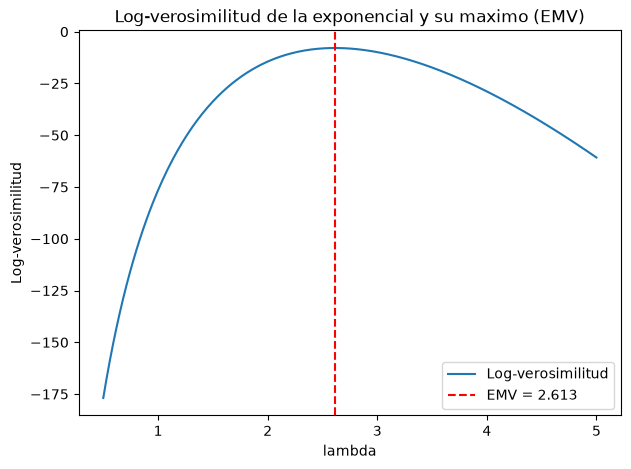

In [75]:
lam_grid = np.linspace(0.5, 5, 300)
log_verosim = np.array([-log_verosimilitud_negativa(l, muestra_exp) for l in lam_grid])

plt.figure()
plt.plot(lam_grid, log_verosim, label="Log-verosimilitud")
plt.axvline(lam_emv_formula, color="red", linestyle="--", label=f"EMV = {lam_emv_formula:.3f}")
plt.xlabel("lambda")
plt.ylabel("Log-verosimilitud")
plt.title("Log-verosimilitud de la exponencial y su maximo (EMV)")
plt.legend()
plt.show()

**Interpretación:** la optimización numérica y la fórmula cerrada coinciden, y la gráfica muestra que la log-verosimilitud alcanza su máximo exactamente en $\hat{\lambda}_{EMV} = 1/\bar{x}$. En este ejemplo, el estimador de momentos y el EMV coinciden porque ambos igualan la media muestral con $1/\lambda$; esto no ocurre en general para otras distribuciones.

---
# B. Propiedades de los estimadores

Un mismo parámetro puede estimarse de varias formas; para comparar estimadores se usan tres propiedades:

- **Insesgadez**: $E[\hat{\theta}] = \theta$. En promedio (sobre muchas muestras), el estimador no se desvía sistemáticamente del valor verdadero.
- **Consistencia**: $\hat{\theta}_n \xrightarrow{P} \theta$ conforme $n \to \infty$. Al aumentar el tamaño de muestra, el estimador se concentra cada vez más cerca del valor verdadero.
- **Eficiencia**: entre dos estimadores insesgados, el más eficiente es el que tiene **menor varianza**.

Se ilustra cada propiedad con la media muestral como estimador de la media $\mu$ de una población Normal.

## B.1 Insesgadez

Se repite muchas veces el experimento de tomar una muestra de tamaño $n=30$ de $X \sim N(50, 10^2)$ y calcular la media muestral $\bar{X}$. Si el estimador es insesgado, el promedio de todas estas estimaciones debe acercarse al valor verdadero $\mu = 50$.

In [76]:
mu_verdadero, sigma_verdadero = 50, 10
n = 30
n_repeticiones = 5000

datos_insesgadez = stats.norm(mu_verdadero, sigma_verdadero).rvs(size=(n_repeticiones, n), random_state=rng)
estimaciones_media = datos_insesgadez.mean(axis=1)

sesgo = estimaciones_media.mean() - mu_verdadero

print("Valor verdadero de mu:", mu_verdadero)
print(f"Promedio de las {n_repeticiones} estimaciones:", round(estimaciones_media.mean(), 4))
print("Sesgo estimado (promedio de estimaciones - valor verdadero):", round(sesgo, 5))

Valor verdadero de mu: 50
Promedio de las 5000 estimaciones: 50.0071
Sesgo estimado (promedio de estimaciones - valor verdadero): 0.00707


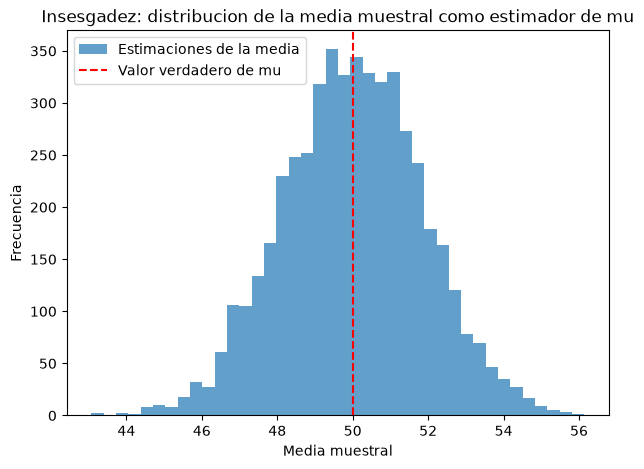

In [77]:
plt.figure()
plt.hist(estimaciones_media, bins=40, color="tab:blue", alpha=0.7, label="Estimaciones de la media")
plt.axvline(mu_verdadero, color="red", linestyle="--", label="Valor verdadero de mu")
plt.xlabel("Media muestral")
plt.ylabel("Frecuencia")
plt.title("Insesgadez: distribucion de la media muestral como estimador de mu")
plt.legend()
plt.show()

**Interpretación:** el sesgo estimado es prácticamente cero y el histograma está centrado en el valor verdadero de $\mu$, confirmando que la media muestral es un estimador insesgado.

## B.2 Consistencia

Se repite el mismo experimento con tamaños de muestra crecientes ($n = 5, 20, 100, 500$) y se observa cómo se dispersan las estimaciones alrededor de $\mu$.

In [78]:
tamanos_n = [5, 20, 100, 500]
n_repeticiones_cons = 2000

estimaciones_por_n = {}
for n_i in tamanos_n:
    datos_n = stats.norm(mu_verdadero, sigma_verdadero).rvs(size=(n_repeticiones_cons, n_i), random_state=rng)
    estimaciones_por_n[n_i] = datos_n.mean(axis=1)
    print(f"n={n_i:>4}: desviacion estandar del estimador = {estimaciones_por_n[n_i].std():.4f} "
          f"(teorica: {sigma_verdadero / np.sqrt(n_i):.4f})")

n=   5: desviacion estandar del estimador = 4.3657 (teorica: 4.4721)
n=  20: desviacion estandar del estimador = 2.1510 (teorica: 2.2361)
n= 100: desviacion estandar del estimador = 0.9903 (teorica: 1.0000)
n= 500: desviacion estandar del estimador = 0.4425 (teorica: 0.4472)


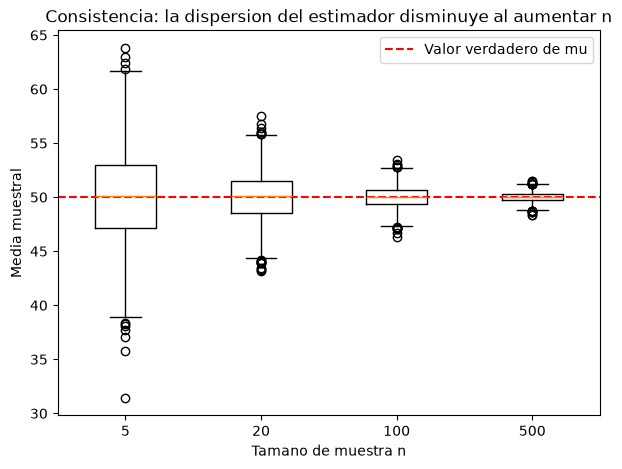

In [79]:
plt.figure()
plt.boxplot([estimaciones_por_n[n_i] for n_i in tamanos_n], tick_labels=[str(n_i) for n_i in tamanos_n])
plt.axhline(mu_verdadero, color="red", linestyle="--", label="Valor verdadero de mu")
plt.xlabel("Tamano de muestra n")
plt.ylabel("Media muestral")
plt.title("Consistencia: la dispersion del estimador disminuye al aumentar n")
plt.legend()
plt.show()

**Interpretación:** conforme $n$ crece, las cajas se estrechan y se concentran alrededor del valor verdadero de $\mu$: la probabilidad de que el estimador se aleje de $\mu$ se vuelve cada vez más pequeña, que es justamente la idea de consistencia.

## B.3 Eficiencia

Se comparan dos estimadores insesgados de $\mu$ para una población Normal: la **media muestral** y la **mediana muestral**. Ambos son insesgados, pero se espera que la media muestral tenga menor varianza (sea más eficiente) cuando los datos provienen de una distribución Normal.

In [80]:
n = 50
n_repeticiones_efi = 5000
datos_efi = stats.norm(mu_verdadero, sigma_verdadero).rvs(size=(n_repeticiones_efi, n), random_state=rng)

estimaciones_media_efi = datos_efi.mean(axis=1)
estimaciones_mediana_efi = np.median(datos_efi, axis=1)

print("Varianza del estimador 'media muestral':  ", round(estimaciones_media_efi.var(), 4))
print("Varianza del estimador 'mediana muestral':", round(estimaciones_mediana_efi.var(), 4))

Varianza del estimador 'media muestral':   2.0101
Varianza del estimador 'mediana muestral': 3.0843


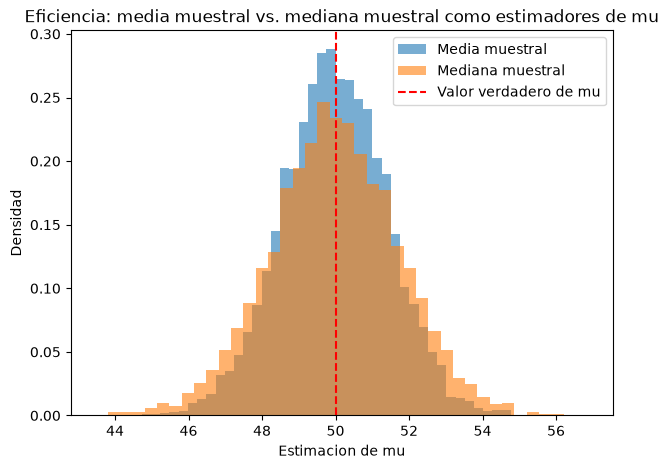

In [81]:
plt.figure()
plt.hist(estimaciones_media_efi, bins=40, alpha=0.6, color="tab:blue", density=True, label="Media muestral")
plt.hist(estimaciones_mediana_efi, bins=40, alpha=0.6, color="tab:orange", density=True, label="Mediana muestral")
plt.axvline(mu_verdadero, color="red", linestyle="--", label="Valor verdadero de mu")
plt.xlabel("Estimacion de mu")
plt.ylabel("Densidad")
plt.title("Eficiencia: media muestral vs. mediana muestral como estimadores de mu")
plt.legend()
plt.show()

**Interpretación:** ambos estimadores están centrados en $\mu$ (son insesgados), pero el histograma de la media muestral es más angosto que el de la mediana muestral: tiene menor varianza y, por lo tanto, es un estimador más **eficiente** de $\mu$ en este caso.

---
# C. Intervalos de confianza

Un **intervalo de confianza (IC)** al $(1-\alpha)\times 100\%$ para un parámetro $\theta$ es un intervalo aleatorio $[\hat{\theta}_{L}, \hat{\theta}_{U}]$, construido a partir de la muestra, tal que si el procedimiento se repite en muchas muestras, aproximadamente el $(1-\alpha)\times 100\%$ de los intervalos construidos contendrán al verdadero valor de $\theta$.

**Interpretación correcta:** la confianza es una propiedad del *procedimiento* a largo plazo, no una probabilidad sobre un intervalo particular ya calculado (una vez calculado, el intervalo contiene o no contiene a $\theta$, sin que haya ya nada aleatorio).

## C.1 Intervalo de confianza para una media

Si $\sigma$ es conocida (o $n$ es grande), se usa la distribución Normal:

$$\bar{x} \pm z_{\alpha/2}\,\frac{\sigma}{\sqrt{n}}.$$

Si $\sigma$ es desconocida (el caso más común en la práctica), se estima con la desviación estándar muestral $s$ y se usa la distribución $t$ de Student con $n-1$ grados de libertad:

$$\bar{x} \pm t_{\alpha/2, \, n-1}\,\frac{s}{\sqrt{n}}.$$

Se calculan ambos intervalos, al 95% de confianza, para una muestra de $X \sim N(50, 10^2)$.

In [82]:
n = 25
muestra_ic = stats.norm(mu_verdadero, sigma_verdadero).rvs(size=n, random_state=rng)

x_barra = muestra_ic.mean()
s = muestra_ic.std(ddof=1)
confianza = 0.95
alfa = 1 - confianza

# Caso varianza conocida (z)
z_critico = stats.norm.ppf(1 - alfa / 2)
margen_error_z = z_critico * sigma_verdadero / np.sqrt(n)
ic_z = (x_barra - margen_error_z, x_barra + margen_error_z)

# Caso varianza desconocida (t de Student)
t_critico = stats.t.ppf(1 - alfa / 2, df=n - 1)
margen_error_t = t_critico * s / np.sqrt(n)
ic_t = (x_barra - margen_error_t, x_barra + margen_error_t)

print("Media muestral =", round(x_barra, 4))
print("Desviacion estandar muestral s =", round(s, 4))
print(f"IC 95% (sigma conocida, distribucion normal): [{ic_z[0]:.4f}, {ic_z[1]:.4f}]")
print(f"IC 95% (sigma desconocida, distribucion t):    [{ic_t[0]:.4f}, {ic_t[1]:.4f}]")

Media muestral = 51.6307
Desviacion estandar muestral s = 10.32
IC 95% (sigma conocida, distribucion normal): [47.7108, 55.5506]
IC 95% (sigma desconocida, distribucion t):    [47.3708, 55.8906]


**Interpretación:** con 95% de confianza, el verdadero valor de $\mu$ está cubierto por intervalos construidos con este procedimiento en el 95% de las muestras repetidas; el intervalo basado en la distribución $t$ es ligeramente más ancho que el basado en la Normal porque incorpora la incertidumbre adicional de estimar $\sigma$ con $s$.

## C.2 Intervalo de confianza para una proporción

Para una proporción muestral $\hat{p}$ calculada a partir de $n$ ensayos Bernoulli, y usando la aproximación Normal (válida cuando $n\hat{p}$ y $n(1-\hat{p})$ son suficientemente grandes),

$$\hat{p} \pm z_{\alpha/2}\sqrt{\frac{\hat{p}(1-\hat{p})}{n}}.$$

Ejemplo: en una encuesta a $n=150$ personas, $\hat{p}$ es la proporción que prefiere cierto producto (simulada con una probabilidad verdadera de 0.3).

In [83]:
n_prop = 150
p_verdadero = 0.3
datos_prop = rng.binomial(1, p_verdadero, size=n_prop)

p_hat = datos_prop.mean()
error_estandar_p = np.sqrt(p_hat * (1 - p_hat) / n_prop)
z_critico = stats.norm.ppf(1 - alfa / 2)
ic_prop = (p_hat - z_critico * error_estandar_p, p_hat + z_critico * error_estandar_p)

print("Proporcion muestral p_hat =", round(p_hat, 4))
print(f"IC 95% para la proporcion: [{ic_prop[0]:.4f}, {ic_prop[1]:.4f}]")

Proporcion muestral p_hat = 0.3267
IC 95% para la proporcion: [0.2516, 0.4017]


**Interpretación:** se tiene 95% de confianza en que el intervalo calculado contiene la verdadera proporción poblacional. Este es un enunciado sobre el procedimiento, no sobre el valor de $p$: si se repitiera la encuesta muchas veces, aproximadamente el 95% de los intervalos construidos de esta forma contendrían al verdadero valor de $p$.

## C.3 Cobertura de los intervalos de confianza

Para ilustrar el significado frecuentista de la confianza, se repite 100 veces el experimento de tomar una muestra de tamaño $n=25$ de $X \sim N(50, 10^2)$ y construir el IC del 95% para $\mu$ (usando la distribución $t$). Se grafican los 100 intervalos y se cuenta qué porcentaje contiene al verdadero valor de $\mu$.

In [84]:
n_intervalos = 100
n_muestra_cobertura = 25
t_critico = stats.t.ppf(1 - alfa / 2, df=n_muestra_cobertura - 1)

limites_inferiores = np.empty(n_intervalos)
limites_superiores = np.empty(n_intervalos)

for i in range(n_intervalos):
    m = stats.norm(mu_verdadero, sigma_verdadero).rvs(size=n_muestra_cobertura, random_state=rng)
    xb = m.mean()
    se = m.std(ddof=1) / np.sqrt(n_muestra_cobertura)
    limites_inferiores[i] = xb - t_critico * se
    limites_superiores[i] = xb + t_critico * se

contiene_mu = (limites_inferiores <= mu_verdadero) & (mu_verdadero <= limites_superiores)
cobertura_empirica = contiene_mu.mean()

print(f"De los {n_intervalos} intervalos construidos, {contiene_mu.sum()} contienen a mu "
      f"({cobertura_empirica * 100:.1f}% de cobertura empirica; el valor nominal es 95%)")

De los 100 intervalos construidos, 91 contienen a mu (91.0% de cobertura empirica; el valor nominal es 95%)


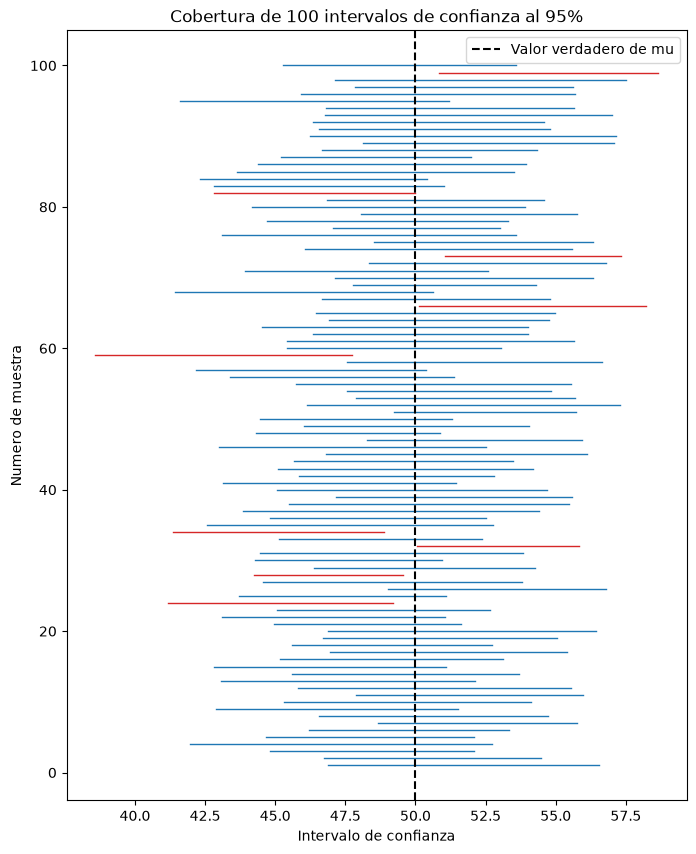

In [85]:
plt.figure(figsize=(8, 10))
indices = np.arange(1, n_intervalos + 1)
colores = np.where(contiene_mu, "tab:blue", "tab:red")
for i in indices:
    plt.plot(
        [limites_inferiores[i - 1], limites_superiores[i - 1]], [i, i],
        color=colores[i - 1], linewidth=1,
    )
plt.axvline(mu_verdadero, color="black", linestyle="--", label="Valor verdadero de mu")
plt.xlabel("Intervalo de confianza")
plt.ylabel("Numero de muestra")
plt.title("Cobertura de 100 intervalos de confianza al 95%")
plt.legend()
plt.show()

**Interpretación:** la gran mayoría de los intervalos (en azul) contienen al valor verdadero de $\mu$, y solo unos pocos (en rojo) lo dejan fuera; la proporción de intervalos azules es cercana al 95% nominal. Esto ilustra que "95% de confianza" describe el comportamiento del procedimiento a largo plazo, no la probabilidad de un intervalo individual ya calculado.

---
## Conclusión del Notebook 3

Los estimadores son la herramienta con la que se traduce la información de una muestra en una aproximación de un parámetro poblacional desconocido. El método de momentos y la estimación por máxima verosimilitud ofrecen dos caminos distintos para construir estimadores, que en algunos casos (como se vio con la exponencial) coinciden y en otros no.

Evaluar un estimador no termina en calcular su valor: sus propiedades (insesgadez, consistencia y eficiencia) determinan qué tan confiable es. Un buen estimador no se desvía sistemáticamente del valor verdadero (insesgadez), mejora conforme se dispone de más datos (consistencia) y aprovecha la información disponible de la manera más precisa posible (eficiencia).

Finalmente, los intervalos de confianza extienden la estimación puntual reconociendo explícitamente la incertidumbre muestral: en lugar de reportar un solo número, se reporta un rango de valores plausibles junto con el nivel de confianza del procedimiento que lo generó. La simulación de cobertura de la sección C.3 conecta directamente con la Ley de los Grandes Números y el Teorema Central del Límite del Notebook 2, que son la base teórica que garantiza el comportamiento de estos intervalos a largo plazo.

---
## Bibliografía

- Rincón, L. (2014). *Curso elemental de probabilidad y estadística*. Facultad de Ciencias, UNAM.
- Ross, S. M. (2010). *A First Course in Probability* (8a ed.). Pearson.
- Mood, A. M., Graybill, F. A., & Boes, D. C. (1974). *Introduction to the Theory of Statistics* (3a ed.). McGraw-Hill.
- Mendenhall, W., Beaver, R. J., & Beaver, B. M. (2013). *Introduction to Probability and Statistics* (14a ed.). Cengage Learning.